# Random Forest for EMG Hand Gesture Classification

## Importing Libraries

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

## Create CSV File from Data

### Step 1: Import Libraries

In [5]:
from pathlib import Path

import os
import pandas as pd

### Step 2: Set the Path to master folder
Adjust this path to where you've saved the EMG data

In [6]:
master_folder = Path("EMG_data_for_gestures-master")

### Step 3: Iterate through subfolders and read each TXT file
Loop through each subfolder, read text files, and concatenate data.

In [7]:
all_data = []
file_count = 0

for i in range(1, 37):
    f_num = i
    subfolder = os.path.join(master_folder, str(f_num))
    if f_num < 10:
        subfolder = os.path.join(master_folder, "0" + str(f_num))

    for filename in os.listdir(subfolder):
        if filename.endswith(".txt"):
            filepath = os.path.join(subfolder, filename)
            data = pd.read_csv(filepath, delim_whitespace=True)
            data["subject_number"] = i
            data = data[data["class"] != 0] # Exclude rows where class is 0
            all_data.append(data)

### Step 4: Concatenate all data and save to CSV
Concatenate all data into single DataFrame and save as CSV file

In [8]:
combined_data = pd.concat(all_data, ignore_index=True)
combined_data.to_csv("EMG_gestures_data.csv", index=False)

## Loading the Data

In [9]:
combined_data = pd.read_csv("EMG_gestures_data.csv")

combined_data.head()

,time,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class,subject_number
0,2400,-0.00001,0.00000,-0.00001,0.00000,0.00000,-0.00001,-0.00001,0.00001,1.0,1
1,2401,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1.0,1
2,2402,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1.0,1
3,2403,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1.0,1
4,2404,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1.0,1


## Preparing the Data

In [10]:
X = combined_data.drop(columns=['class'])
y = combined_data['class']

nan_indices = y[y.isna()].index
X_clean = X.drop(nan_indices).reset_index(drop=True)
y_clean = y.drop(nan_indices).reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

print("Length of training set:", len(X_train))
print("Length of test set:", len(X_test))

Length of training set: 1210200
Length of test set: 302550


## Training Random Forest

In [24]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

rf_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Making Predictions

In [25]:
y_pred = rf_classifier.predict(X_test)

print(y_pred)

[6. 5. 2. ... 3. 4. 6.]


## Evalution

              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00     49973
         2.0       1.00      1.00      1.00     48932
         3.0       1.00      1.00      1.00     50003
         4.0       1.00      1.00      1.00     50031
         5.0       1.00      0.99      1.00     50393
         6.0       1.00      1.00      1.00     50530
         7.0       1.00      0.98      0.99      2688

    accuracy                           1.00    302550
   macro avg       1.00      0.99      1.00    302550
weighted avg       1.00      1.00      1.00    302550



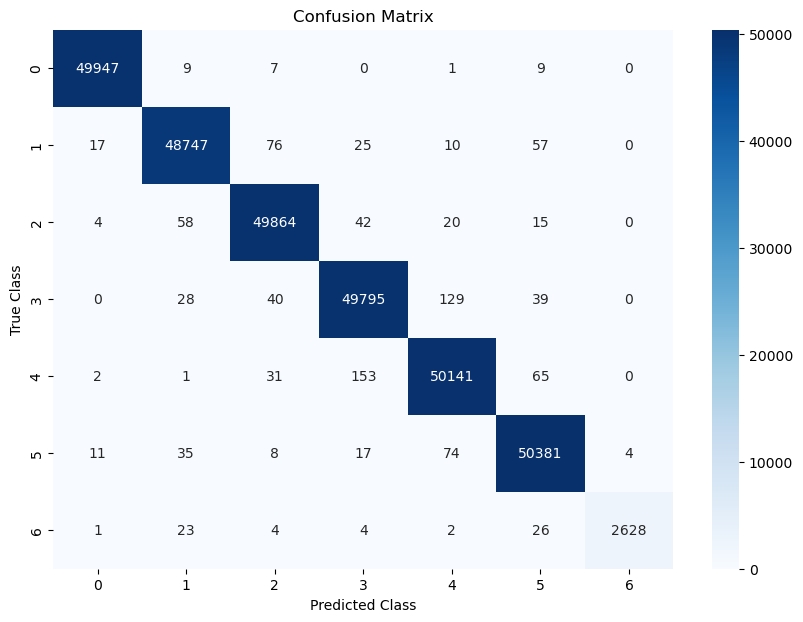

In [26]:
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

# SVM

## Training

In [27]:
from sklearn.svm import SVC

svm_classifier = SVC(kernel='rbf')

svm_classifier.fit(X_train, y_train)

## Predictions

In [ ]:
y_pred = svm_classifier.predict(X_test)

print(y_pred)

## Evaluation

In [ ]:
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

## Training

In [11]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

## Predictions

In [12]:
y_pred = knn.predict(X_test)

print(y_pred)

[6. 5. 2. ... 3. 1. 5.]


## Evaluation

              precision    recall  f1-score   support

         1.0       0.79      0.86      0.82     49973
         2.0       0.81      0.80      0.80     48932
         3.0       0.79      0.82      0.80     50003
         4.0       0.78      0.74      0.76     50031
         5.0       0.75      0.76      0.76     50393
         6.0       0.78      0.72      0.75     50530
         7.0       0.87      0.69      0.77      2688

    accuracy                           0.78    302550
   macro avg       0.79      0.77      0.78    302550
weighted avg       0.78      0.78      0.78    302550



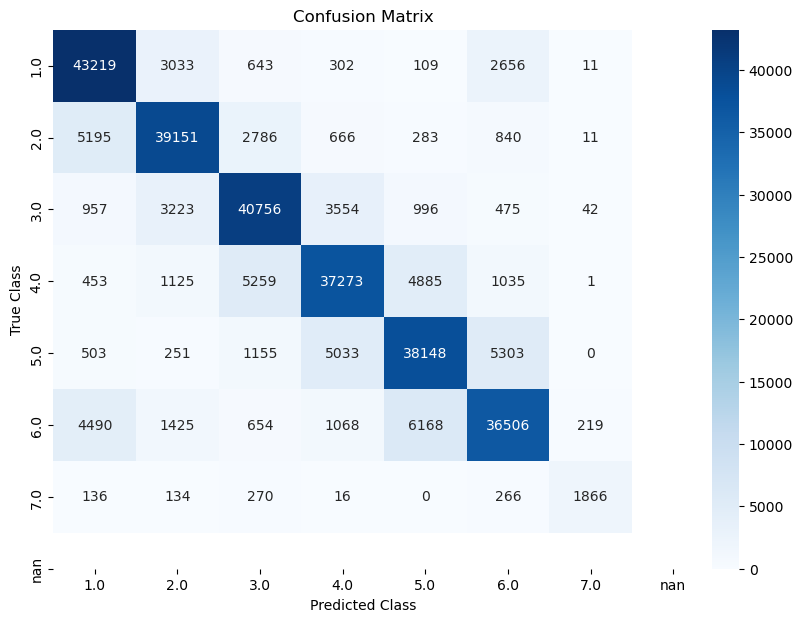

In [13]:
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

## Training

In [17]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
y_train = y_train.astype(int) - 1
y_test = y_test.astype(int) - 1
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

## Predictions

In [18]:
y_pred = xgb.predict(X_test)

print(y_pred)

[5 4 1 ... 2 3 5]


## Evaluation

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     49973
           1       0.99      0.99      0.99     48932
           2       0.99      0.99      0.99     50003
           3       0.99      0.99      0.99     50031
           4       0.98      0.99      0.99     50393
           5       0.99      0.99      0.99     50530
           6       1.00      1.00      1.00      2688

    accuracy                           0.99    302550
   macro avg       0.99      0.99      0.99    302550
weighted avg       0.99      0.99      0.99    302550



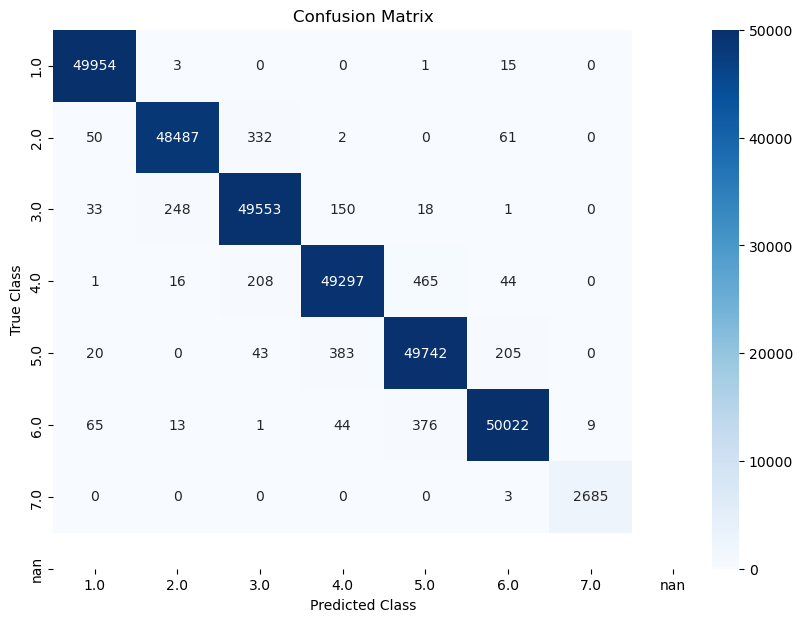

In [19]:
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()